# Simple algorithm presentation and analysis examples

First let's generate some fictional fitness data to plot. We are generating two series of points, the kind of thing we see when comparing the fitness of Algorithm A against Algorithm B.

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import random
%matplotlib inline

np.random.seed(10)

In [12]:
gens = 100
t = np.arange(gens)

In [13]:
mean_fitnesses1 = np.random.exponential(scale=1.0, size=gens)
mean_fitnesses1.sort()

mean_fitnesses2 = np.random.exponential(scale=2.5, size=gens)
mean_fitnesses2.sort()

In [14]:
std1 = [random.uniform(0.75,1.0) for x in range(gens)]
std2 = [random.uniform(0.9,1.2) for x in range(gens)]

When plotting data for presentation, it's important to
*   make the figure big enough to be readable
*   make the font size big enough to be readable
*   label the axes properly
*   add a legend identifying the series

The plot below uses a 'ribbon plot' to show the standard deviation around the data, rather than plotting bars.





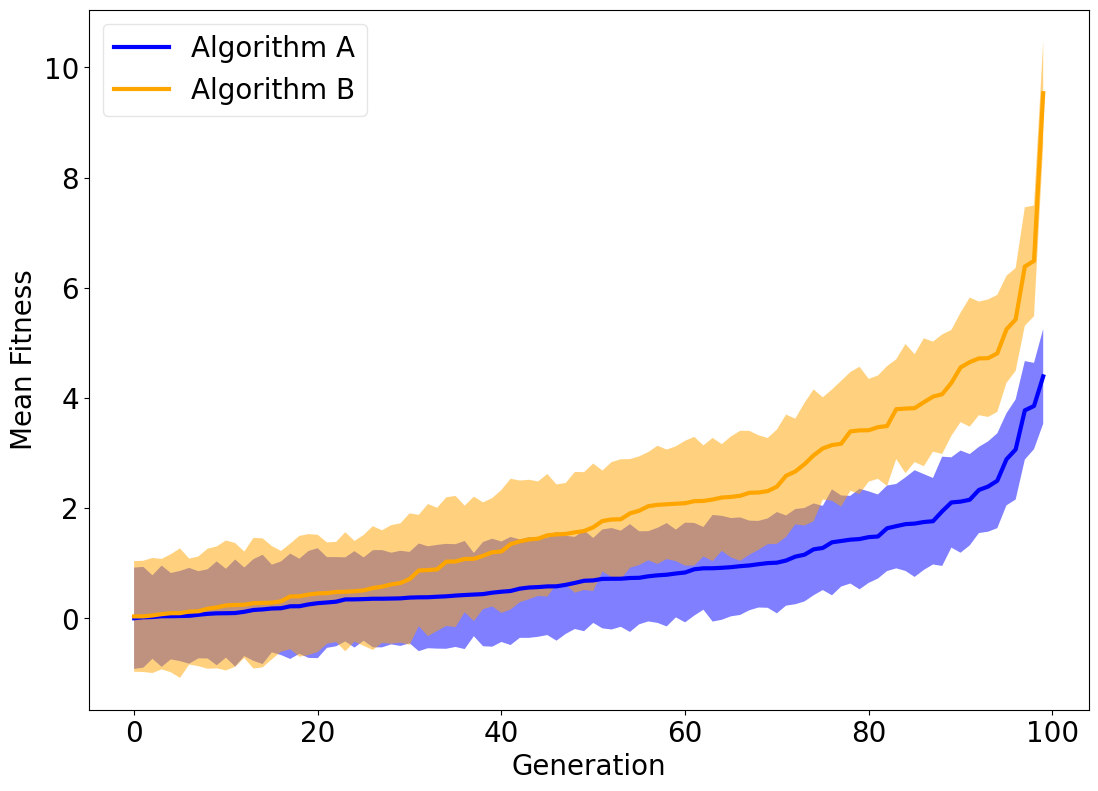

In [15]:
plt.rcParams.update({'font.size': 20})

fig = plt.figure(figsize =(10, 7))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlabel('Generation')
ax.set_ylabel('Mean Fitness')
ax.plot(t, mean_fitnesses1, lw=3, label='Algorithm A', color='blue')
ax.fill_between(t, mean_fitnesses1+std1, mean_fitnesses1-std1, facecolor='blue', alpha=0.5)
ax.plot(t, mean_fitnesses2, lw=3, label='Algorithm B', color='orange')
ax.fill_between(t, mean_fitnesses2+std2, mean_fitnesses2-std2, facecolor='orange', alpha=0.5)
ax.legend(loc='best', fancybox=True, framealpha=0.5)

This plot shows how Algorithms A and B perform over time. It appears that Algorithm B is better than Algorithm A, but we should use a statistical test for this.

Above, we only generated data that looks like the average fitness. To test whether A is better than B, we need to look at the populations after evolution has finished. To simulate this, the code below generate random numbers from Normal distributions with different means.

We can then take these "final populations" for Algorithm A and Algorithm B and show their distributions using a box plot.

<ipython-input-16-5188dd13e141>:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['A', 'B'] )


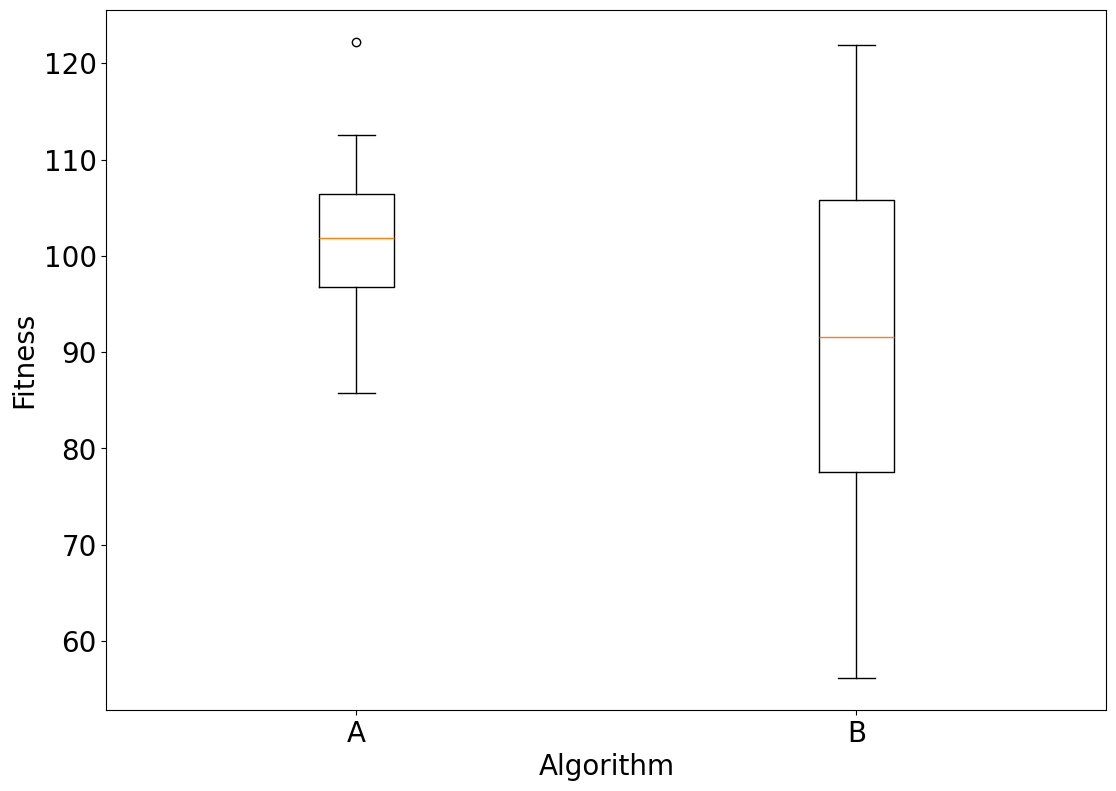

In [16]:
data_A = np.random.normal(100, 10, 20)
data_B = np.random.normal(95, 20, 20)

data = [data_A, data_B] #

fig = plt.figure(figsize =(10, 7))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xticklabels(['A', 'B'] )

ax.set_xlabel('Algorithm')
ax.set_ylabel('Fitness')

bp = ax.boxplot(data)

To see whether A is really better than B, we need to test for a difference between the individuals in A and B

In [17]:
print('data1: mean=%.3f stdv=%.3f' % (np.mean(data_A), np.std(data_A)))
print('data2: mean=%.3f stdv=%.3f' % (np.mean(data_B), np.std(data_B)))

data1: mean=101.818 stdv=8.164
data2: mean=91.930 stdv=18.784


To test whether the difference betwene th etwo means is significant, we'll use the Mann-Whitney U test. This is a nonparametric statistical significance test for determining whether two independent samples were drawn from a population with the same distribution.

The two samples are combined and rank ordered together. The strategy is to determine if the values from the two samples are randomly mixed in the rank ordering or if they are clustered at opposite ends when combined. A random rank order would mean that the two samples are not different, while a cluster of one sample values would indicate a difference between them.

Normally, for the test to be effective, it requires at least 20 observations in each data sample.

In terms of a Genetic Algorithm, the samples are fitnesses of the individuals in each population that we are comparing. In practice these are always going to be large enouigh to use the Mann-Whitney U test.

In [18]:
from scipy.stats import mannwhitneyu

In [19]:
stat, p = mannwhitneyu(data_A, data_B)
print('Statistics=%.3f, p=%.3f' % (stat, p))

Statistics=270.000, p=0.060


The p-value is the probability that you would see the observed difference by chance when drawing two samples from the same distribution. The bigger your observed difference is, the smaller the probability that you would see this by chance.

We need to choose a threshold to compare the calculated p-value to. The most common threshold is p < 0.05; that is, when you would expect to find a test statistic as extreme as the one calculated by your test only 5% of the time. But if we want greater confidence, we could choose a thresholds of 0.01, or even 0.001.

Given how it is calculated, the p-value cannot be exactly zero - the test may report "p = 0.000" but this must be understood as a very small value rounded to 0.000.

The U value: pick one value from group A and also pick a value from group B. Record which group has the larger value. Repeat for all values in the two groups.  Total up the number of times that the value in A is larger than B, and the number of times the value in B is larger than the value in A. The smaller of these two values is U. So if U = 0 then all values in one group are larger than all values in another. Basically, the smaller the U value, the more different the groups, but the value of U will be related to sample size.

In [ ]:
print('Difference in means (A<->B): ' + str(np.mean(data_A) - np.mean(data_B)) )